<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\myles\AppData\Local\Temp\ipykernel_100196\4222033256.py:6: SyntaxWarning: invalid escape sequence '\m'
  titles = ['$\mu_r = 0$', '$\mu_s = 1$']
C:\Users\myles\AppData\Local\Temp\ipykernel_100196\4222033256.py:6: SyntaxWarning: invalid escape sequence '\m'
  titles = ['$\mu_r = 0$', '$\mu_s = 1$']


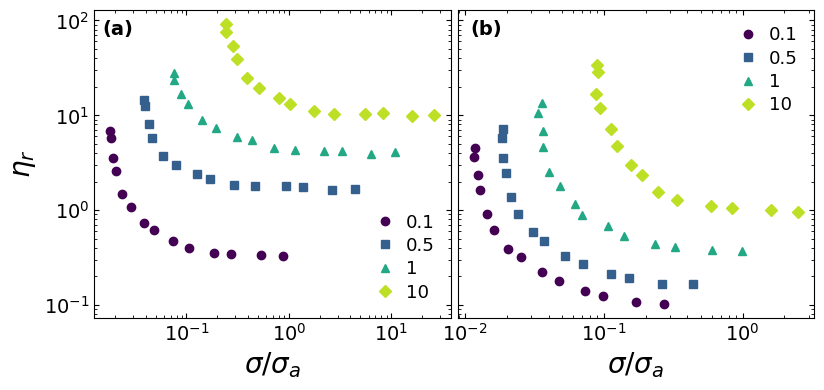

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

fig_names = ['fric_sweep_1.pkl', 'fric_sweep_2.pkl']
titles = ['$\mu_r = 0$', '$\mu_s = 1$']

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, constrained_layout=False)

for ax_new, fname, title in zip(axes, fig_names, titles):
    with open(fname, 'rb') as f:
        fig_old = pickle.load(f)
    plt.close(fig_old)

    ax_old = fig_old.axes[0]
    lines = ax_old.get_lines()
    colours = plt.cm.viridis(np.linspace(0, 0.9, len(lines)))

    for line, colour in zip(lines, colours):
        ax_new.plot(line.get_xdata(), line.get_ydata(),
                    marker=line.get_marker(),
                    color=colour,
                    linestyle=line.get_linestyle(),
                    markersize=6,
                    label=line.get_label())

    ax_new.set_xscale('log')
    ax_new.set_yscale('log')
    ax_new.set_xlabel(r'$\sigma / \sigma_a$', fontsize=20, fontweight='bold')
    ax_new.minorticks_on()
    ax_new.tick_params(axis='both', which='both', direction='in',
                       top=True, right=True, labelsize=14)
    ax_new.legend( fontsize=13, frameon=False,
                  handlelength=1.5, borderpad=0.4,
                  labelspacing=0.3, handletextpad=0.4)

axes[0].set_ylabel(r'$\eta_r$', fontsize=20, fontweight='bold')
axes[0].tick_params(axis='y', labelleft=True, labelsize=14)
axes[0].legend(loc='lower right', fontsize=13, frameon=False,
               handlelength=1.5, borderpad=0.4,
               labelspacing=0.3, handletextpad=0.4)
axes[0].text(.015, 70, '(a)', fontsize=14, fontweight='bold')
axes[1].text(.011, 70, '(b)', fontsize=14, fontweight='bold')
for ax in axes[1:]:
    ax.tick_params(axis='y', labelleft=False)

fig.subplots_adjust(left=0.08, right=0.98, top=0.95, bottom=0.18, wspace=0.02)
plt.savefig('fric_sweep_combined.png', dpi=1200)
plt.show()